# 03 — Labeling

Compute future returns for each horizon and assign trading signal labels.

**Thresholds:**
| Signal | 3 months | 6 months | 1 year |
|--------|----------|----------|--------|
| Strong Sell | < -8% | < -12% | < -15% |
| Sell | -8% to -3% | -12% to -4% | -15% to -5% |
| Hold | -3% to +3% | -4% to +5% | -5% to +8% |
| Buy | +3% to +8% | +5% to +12% | +8% to +20% |
| Strong Buy | > +8% | > +12% | > +20% |

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

In [2]:
# Fetch test stocks
test_tickers = ["AAPL", "MSFT", "JPM", "JNJ", "XOM"]
data = yf.download(test_tickers, period="5y", group_by="ticker", auto_adjust=True)
print(f"Shape: {data.shape}")
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")

[*********************100%***********************]  5 of 5 completed

Shape: (1255, 25)
Date range: 2021-03-24 to 2026-03-23


## 1. Define Labeling Thresholds

In [3]:
HORIZONS = {
    "3m": 63,   # ~3 months in trading days
    "6m": 126,  # ~6 months
    "1y": 252,  # ~1 year
}

# Thresholds: (strong_sell, sell, hold, buy) boundaries
# e.g. for 3m: < -8% = Strong Sell, -8% to -3% = Sell, -3% to +3% = Hold, +3% to +8% = Buy, > +8% = Strong Buy
THRESHOLDS = {
    "3m": (-8, -3, 3, 8),
    "6m": (-12, -4, 5, 12),
    "1y": (-15, -5, 8, 20),
}

SIGNAL_LABELS = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]
SIGNAL_MAP = {label: i for i, label in enumerate(SIGNAL_LABELS)}

print("Horizons (trading days):", HORIZONS)
print("Thresholds (%):", THRESHOLDS)
print("Signal labels:", SIGNAL_LABELS)

Horizons (trading days): {'3m': 63, '6m': 126, '1y': 252}
Thresholds (%): {'3m': (-8, -3, 3, 8), '6m': (-12, -4, 5, 12), '1y': (-15, -5, 8, 20)}
Signal labels: ['Strong Sell', 'Sell', 'Hold', 'Buy', 'Strong Buy']


## 2. Labeling Function

In [5]:
def compute_future_returns(close: pd.Series, horizon_days: int) -> pd.Series:
    """Compute the percentage return `horizon_days` into the future."""
    return (close.shift(-horizon_days) / close - 1) * 100


def assign_signal(returns: pd.Series, thresholds: tuple) -> pd.Series:
    """Assign a signal label based on return thresholds.
    
    thresholds = (strong_sell_bound, sell_bound, buy_bound, strong_buy_bound)
    """
    ss, s, b, sb = thresholds
    conditions = [
        returns < ss,
        (returns >= ss) & (returns < s),
        (returns >= s) & (returns < b),
        (returns >= b) & (returns < sb),
        returns >= sb,
    ]
    return pd.Series(
        np.select(conditions, SIGNAL_LABELS, default=""),
        index=returns.index,
    ).replace("", np.nan)


# Test on AAPL
aapl_close = data["AAPL"]["Close"]

for horizon_name, horizon_days in HORIZONS.items():
    future_ret = compute_future_returns(aapl_close, horizon_days)
    signal = assign_signal(future_ret, THRESHOLDS[horizon_name])
    print(f"\n--- {horizon_name} ({horizon_days} days) ---")
    print(f"Future return range: {future_ret.min():.1f}% to {future_ret.max():.1f}%")
    print(f"Signal distribution:\n{signal.value_counts().to_string()}")
    print(f"NaN (no future data): {signal.isna().sum()}")


--- 3m (63 days) ---
Future return range: -29.5% to 37.5%
Signal distribution:
Strong Buy     479
Strong Sell    227
Hold           191
Buy            168
Sell           127
NaN (no future data): 63

--- 6m (126 days) ---
Future return range: -27.3% to 54.3%
Signal distribution:
Strong Buy     462
Hold           229
Buy            180
Sell           152
Strong Sell    106
NaN (no future data): 126

--- 1y (252 days) ---
Future return range: -30.2% to 53.6%
Signal distribution:
Strong Buy     375
Buy            296
Hold           225
Sell            76
Strong Sell     31
NaN (no future data): 252


## i3. Class Distribution Across All Test Stocks

Check if the thresholds produce a reasonable distribution. Target: no class below ~12% or above ~30%.


--- 3m (all 5 stocks combined) ---
   Strong Sell:   809 ( 13.6%)
          Sell:   781 ( 13.1%)
          Hold:  1184 ( 19.9%)
           Buy:  1042 ( 17.5%)
    Strong Buy:  2144 ( 36.0%) ⚠

--- 6m (all 5 stocks combined) ---
   Strong Sell:   408 (  7.2%) ⚠
          Sell:   702 ( 12.4%)
          Hold:  1447 ( 25.6%)
           Buy:   881 ( 15.6%)
    Strong Buy:  2207 ( 39.1%) ⚠

--- 1y (all 5 stocks combined) ---
   Strong Sell:   284 (  5.7%) ⚠
          Sell:   549 ( 10.9%) ⚠
          Hold:  1157 ( 23.1%)
           Buy:  1051 ( 21.0%)
    Strong Buy:  1974 ( 39.4%) ⚠


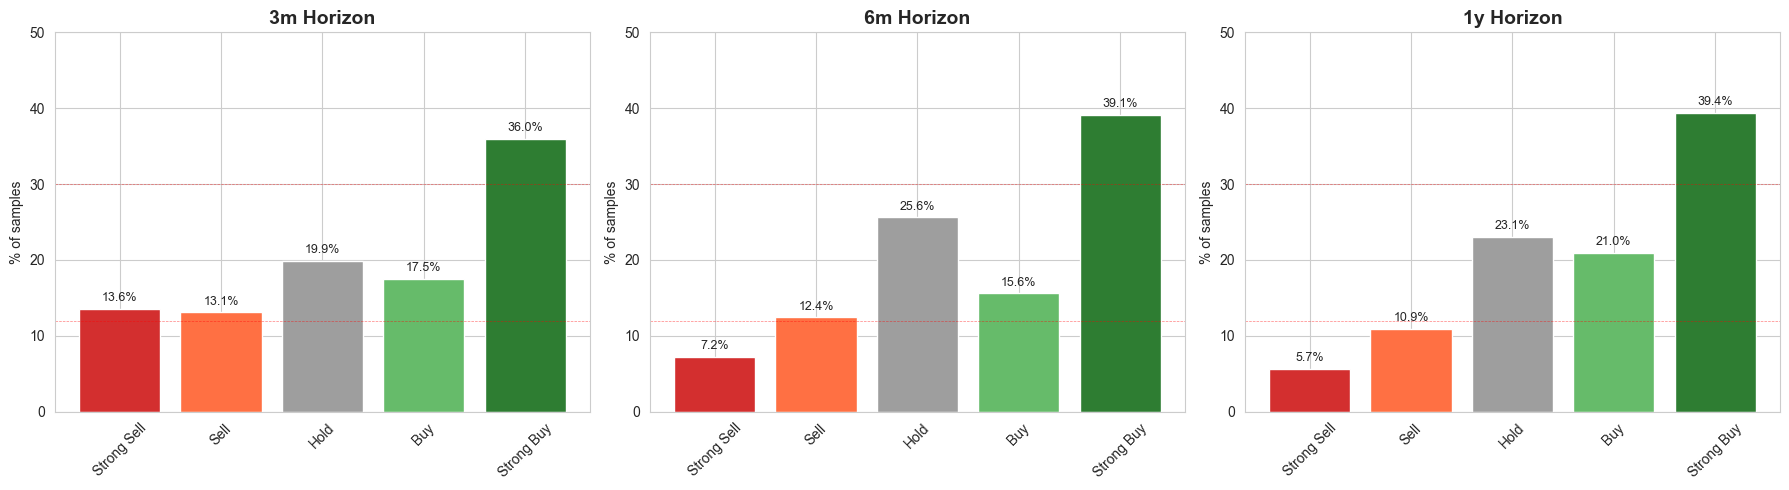

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#d32f2f", "#ff7043", "#9e9e9e", "#66bb6a", "#2e7d32"]

for idx, (horizon_name, horizon_days) in enumerate(HORIZONS.items()):
    all_signals = []
    
    for ticker in test_tickers:
        close = data[ticker]["Close"]
        future_ret = compute_future_returns(close, horizon_days)
        signal = assign_signal(future_ret, THRESHOLDS[horizon_name])
        all_signals.append(signal)
    
    combined = pd.concat(all_signals)
    counts = combined.value_counts().reindex(SIGNAL_LABELS).fillna(0)
    pcts = counts / counts.sum() * 100
    
    bars = axes[idx].bar(SIGNAL_LABELS, pcts, color=colors)
    axes[idx].set_title(f"{horizon_name} Horizon", fontsize=14, fontweight="bold")
    axes[idx].set_ylabel("% of samples")
    axes[idx].set_ylim(0, 50)
    axes[idx].axhline(y=12, color="red", linestyle="--", linewidth=0.5, alpha=0.5)
    axes[idx].axhline(y=30, color="red", linestyle="--", linewidth=0.5, alpha=0.5)
    axes[idx].tick_params(axis="x", rotation=45)
    
    for bar, pct in zip(bars, pcts):
        axes[idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                       f"{pct:.1f}%", ha="center", fontsize=9)
    
    print(f"\n--- {horizon_name} (all {len(test_tickers)} stocks combined) ---")
    for label, count, pct in zip(SIGNAL_LABELS, counts, pcts):
        flag = " ⚠" if pct < 12 or pct > 30 else ""
        print(f"  {label:>12}: {int(count):5d} ({pct:5.1f}%){flag}")

plt.tight_layout()
plt.show()

## 4. Future Return Distributions

Visualize the raw future return distributions per horizon to understand the data.

3m: mean=4.5%, median=3.9%, std=11.2%
6m: mean=9.0%, median=7.1%, std=16.0%
1y: mean=16.8%, median=12.7%, std=23.2%


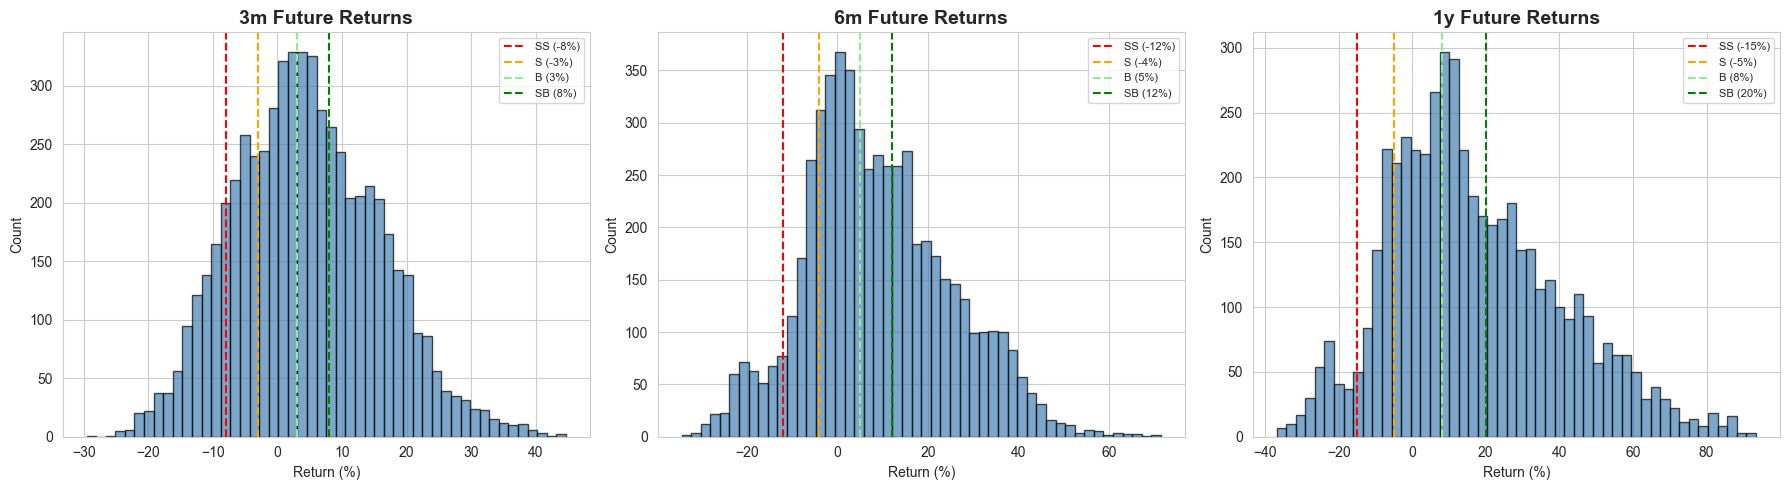

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (horizon_name, horizon_days) in enumerate(HORIZONS.items()):
    all_returns = []
    for ticker in test_tickers:
        close = data[ticker]["Close"]
        future_ret = compute_future_returns(close, horizon_days).dropna()
        all_returns.append(future_ret)
    
    combined_returns = pd.concat(all_returns)
    
    axes[idx].hist(combined_returns, bins=50, edgecolor="black", alpha=0.7, color="steelblue")
    
    # Draw threshold lines
    ss, s, b, sb = THRESHOLDS[horizon_name]
    for thresh, color, label in [(ss, "red", "SS"), (s, "orange", "S"), (b, "lightgreen", "B"), (sb, "green", "SB")]:
        axes[idx].axvline(x=thresh, color=color, linestyle="--", linewidth=1.5, label=f"{label} ({thresh}%)")
    
    axes[idx].set_title(f"{horizon_name} Future Returns", fontsize=14, fontweight="bold")
    axes[idx].set_xlabel("Return (%)")
    axes[idx].set_ylabel("Count")
    axes[idx].legend(fontsize=8)
    
    print(f"{horizon_name}: mean={combined_returns.mean():.1f}%, median={combined_returns.median():.1f}%, std={combined_returns.std():.1f}%")

plt.tight_layout()
plt.show()